# Vibration Isolation — FC/IMU and Payload
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

The single EDF is a high-RPM rotating machine on a stiff CFRP monocoque. Its
dominant forcing is the **1-per-rev shaft imbalance** at the shaft frequency
(`f_shaft = RPM / 60`, derived from the same `rpm_from_diameter` law the rest
of the pipeline uses); blade-pass (`n_blades × f_shaft`) is far higher. That
1/rev line corrupts the IMU attitude estimate and blurs the EO payload.

This notebook soft-mounts the **FC/IMU cluster** and the **payload** on
vibration isolators and sizes each as a 1-DOF base-excitation isolator:
corner frequency, transmissibility at the forcing frequency, static sag,
sway/rattle space, isolator stiffness, and hardware mass. The sway space is
handed to `fuselage_design` (it costs packing volume); the isolator hardware
is carved into the mass budget.

Because the forcing is far above any practical isolator corner frequency, a
soft mount at f_n ≈ 40–60 Hz achieves large attenuation with only a fraction
of a millimetre of static deflection — so the packing-volume cost is small.

## Inputs

- `config/vibration.yaml` — isolation target, damping, shock load, isolated
  FC/IMU mass, isolator counts/mass.
- rotor RPM (`rpm_from_diameter`) + `config/prop_geometry.yaml` `n_blades`
  → forcing frequency.
- mission payload mass (soft-mounted whole).

## Outputs

- `out/vibration.yaml`
- `out/vibration_transmissibility.png`

---

In [1]:
import sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83"]

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Section 1 — Design Inputs

Re-run the sizing loop from `config/` (same pattern as NB2–NB4) for the
payload mass and the rotor, and derive the EDF forcing frequency.

---

In [2]:
from conceptual_design import (
    run_sizing_loop, Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics
from conceptual_design.vtol_power import VTOLParams, rpm_from_diameter
from conceptual_design.vibration_isolation import (
    VibrationParams, size_isolation, write_vibration_yaml, transmissibility,
)

env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")
vib_p    = VibrationParams.from_yaml(CONFIG_PATH / "vibration.yaml")

with open(CONFIG_PATH / "prop_geometry.yaml") as f:
    n_blades = int(yaml.safe_load(f)["n_blades"])

result = run_sizing_loop(
    m_payload_kg=mission.payload_kg, mission=mission, aero=aero, batt=batt,
    wf=wf, prop_params=prop, ff_params=ff, ws_params=ws, env=env,
    D_rotor_m=rotor.D_rotor_m, P_hotel_W=avionics.P_hotel_W,
)

vtol = VTOLParams.from_propulsive(prop, env)
rpm  = rpm_from_diameter(rotor.D_rotor_m, vtol)

print(f"EDF shaft speed   : {rpm:.0f} RPM  -> {rpm/60:.1f} Hz (1/rev)")
print(f"Blade count       : {n_blades}  -> blade-pass {rpm/60*n_blades:.0f} Hz")
print(f"Payload (isolated): {result.m_payload_kg:.3f} kg")
print(f"FC/IMU (isolated) : {vib_p.m_fc_imu_kg:.3f} kg  (subset of avionics {result.m_avionics_kg:.3f} kg)")
print(f"Target            : T <= {vib_p.target_transmissibility:.2f} "
      f"({100*(1-vib_p.target_transmissibility):.0f}% attenuation), zeta = {vib_p.damping_ratio:.2f}")

EDF shaft speed   : 12678 RPM  -> 211.3 Hz (1/rev)
Blade count       : 11  -> blade-pass 2324 Hz
Payload (isolated): 0.500 kg
FC/IMU (isolated) : 0.060 kg  (subset of avionics 0.245 kg)
Target            : T <= 0.10 (90% attenuation), zeta = 0.10


# Section 2 — Isolator Sizing

Size the corner frequency `f_n` as high (stiffest, least sway) as still meets
the target transmissibility at the 1/rev forcing, check it sits in the valid
window (above the control bandwidth, below `f_forcing/√2`), and size the
sway space and isolator stiffness/mass for each module.

---

In [3]:
res = size_isolation(rpm, n_blades, result.m_payload_kg, vib_p)

lo, hi = res["f_n_window_hz"]
print(f"Forcing (1/rev)   : {res['f_shaft_hz']:.1f} Hz")
print(f"Corner freq f_n   : {res['f_n_hz']:.1f} Hz   "
      f"(valid window {lo:.0f}-{hi:.0f} Hz -> {'OK' if res['window_ok'] else 'OUT OF WINDOW'})")
print(f"Sway per bay      : {res['sway_mm']:.2f} mm  "
      f"(shock {vib_p.shock_load_g:.0f} g)")
print()
hdr = f"{'module':<10}{'m [kg]':>8}{'f_n [Hz]':>10}{'r':>7}{'T':>8}{'atten':>8}{'d_st [mm]':>11}{'k/iso [N/m]':>13}{'hw [g]':>8}"
print(hdr); print('-'*len(hdr))
for nm, m in res["modules"].items():
    print(f"{nm:<10}{m.m_isolated_kg:>8.3f}{m.f_n_hz:>10.1f}{m.r_ratio:>7.2f}"
          f"{m.transmissibility:>8.3f}{m.attenuation_pct:>7.1f}%{m.delta_static_mm:>11.3f}"
          f"{m.k_isolator_N_m:>13.0f}{m.hw_mass_kg*1e3:>8.0f}")

assert res["window_ok"], "corner frequency outside the valid isolation window"


Forcing (1/rev)   : 211.3 Hz
Corner freq f_n   : 57.8 Hz   (valid window 25-149 Hz -> OK)
Sway per bay      : 0.74 mm  (shock 10 g)

module      m [kg]  f_n [Hz]      r       T   atten  d_st [mm]  k/iso [N/m]  hw [g]
-----------------------------------------------------------------------------------
fc_imu       0.060      57.8   3.66   0.100   90.0%      0.074         1978      16
payload      0.500      57.8   3.66   0.100   90.0%      0.074        16482      16


# Section 3 — Transmissibility Curve

The transmissibility of the sized isolator vs. frequency ratio, with the
1/rev and blade-pass forcing lines and the target. Both forcing lines land
in the isolation region (`r > √2`); the design is set at the 1/rev line
(the harder, lower-frequency case).

---

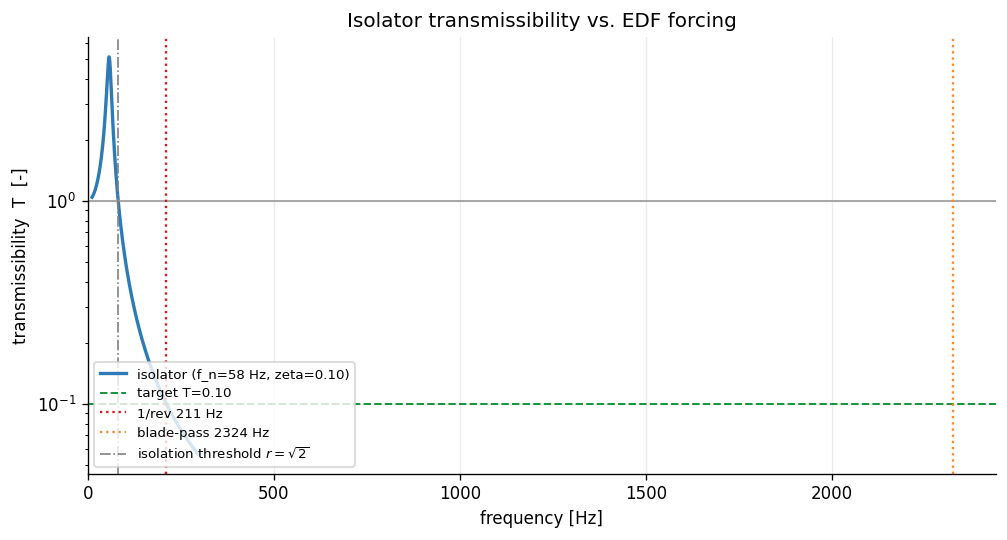

In [4]:
r = np.linspace(0.2, res['f_shaft_hz']/max(res['f_n_hz'],1e-6)*1.4, 600)
T = np.array([transmissibility(ri, vib_p.damping_ratio) for ri in r])
f_hz = r * res['f_n_hz']

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.semilogy(f_hz, T, color=C[0], lw=2, label=f"isolator (f_n={res['f_n_hz']:.0f} Hz, zeta={vib_p.damping_ratio:.2f})")
ax.axhline(1.0, color="0.6", lw=1, ls="-")
ax.axhline(vib_p.target_transmissibility, color=C[2], lw=1.2, ls="--",
           label=f"target T={vib_p.target_transmissibility:.2f}")
ax.axvline(res['f_shaft_hz'], color=C[1], lw=1.4, ls=":",
           label=f"1/rev {res['f_shaft_hz']:.0f} Hz")
ax.axvline(res['f_blade_hz'], color=C[3], lw=1.4, ls=":",
           label=f"blade-pass {res['f_blade_hz']:.0f} Hz")
ax.axvline(res['f_n_hz']*math.sqrt(2), color="0.5", lw=1, ls="-.",
           label=r"isolation threshold $r=\sqrt{2}$")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("transmissibility  T  [-]")
ax.set_title("Isolator transmissibility vs. EDF forcing")
ax.set_xlim(0, res['f_blade_hz']*1.05)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(OUT_PATH / "vibration_transmissibility.png", bbox_inches="tight")
plt.show()

# Section 4 — Output Export

`out/vibration.yaml` — consumed by `fuselage_design` (sway pad fed into the
bay stack; isolator hardware carved from the avionics/structural fractions)
and read for reference downstream.

---

In [5]:
write_vibration_yaml(res, vib_p, OUT_PATH / "vibration.yaml")
print(f"Vibration design written -> {OUT_PATH / 'vibration.yaml'}")

Vibration design written -> D:\Dev\vbat-uav-notebooks\out\vibration.yaml


# Section 5 — Design Summary

---

In [6]:
bar = "=" * 60
fc = res["modules"]["fc_imu"]; pl = res["modules"]["payload"]
print(bar)
print("  VIBRATION ISOLATION SUMMARY".center(60))
print(bar)
print(f"  {'EDF 1/rev forcing':<32}: {res['f_shaft_hz']:8.1f} Hz")
print(f"  {'Blade-pass forcing':<32}: {res['f_blade_hz']:8.0f} Hz")
print(f"  {'Isolator corner f_n':<32}: {res['f_n_hz']:8.1f} Hz")
print(f"  {'Valid window':<32}: {res['f_n_window_hz'][0]:.0f} - {res['f_n_window_hz'][1]:.0f} Hz "
      f"({'OK' if res['window_ok'] else 'OUT'})")
print(f"  {'1/rev attenuation':<32}: {fc.attenuation_pct:8.1f} %")
print(f"  {'Static sag (1 g)':<32}: {fc.delta_static_mm:8.3f} mm")
print(f"  {'Sway space per bay':<32}: {res['sway_mm']:8.2f} mm  ({vib_p.shock_load_g:.0f} g shock)")
print()
print(f"  {'FC/IMU isolators':<32}: {fc.n_isolators} x, k = {fc.k_isolator_N_m:.0f} N/m, {fc.hw_mass_kg*1e3:.0f} g")
print(f"  {'Payload isolators':<32}: {pl.n_isolators} x, k = {pl.k_isolator_N_m:.0f} N/m, {pl.hw_mass_kg*1e3:.0f} g")
print(f"  {'Total isolator hardware':<32}: {(fc.hw_mass_kg+pl.hw_mass_kg)*1e3:8.0f} g")
print(bar)

                 VIBRATION ISOLATION SUMMARY                
  EDF 1/rev forcing               :    211.3 Hz
  Blade-pass forcing              :     2324 Hz
  Isolator corner f_n             :     57.8 Hz
  Valid window                    : 25 - 149 Hz (OK)
  1/rev attenuation               :     90.0 %
  Static sag (1 g)                :    0.074 mm
  Sway space per bay              :     0.74 mm  (10 g shock)

  FC/IMU isolators                : 4 x, k = 1978 N/m, 16 g
  Payload isolators               : 4 x, k = 16482 N/m, 16 g
  Total isolator hardware         :       32 g
